# FAIMM Cross-View Concept Audit — Mars SPICE Pairs

**Scaled-up version of the Earth analog prototype for 4,762 SPICE-registered HiRISE/NAVCAM pairs.**

## Pipeline
```
Phase 0  Setup & config       — scaled hyperparams for N=4,762
Phase 1  Data loading          — Mars SPICE pairs (orbital_path / surface_path JPGs)
Phase 2  Dual-encoder          — InfoNCE contrastive training, frozen DINOv2-small
Phase 3  Sparse Autoencoder    — shared concept dictionary (2048-wide)
Phase 4  Concept survival      — Spearman r per concept across matched pairs
Phase 5  Retrieval & diagnosis — failure diagnosis in concept terms
Phase 6  Visualisation         — audit report figures
Phase 7  ROS export            — checkpoint bundle for May Gazebo integration
```

**Expected outcomes vs Earth analog:**
- Dead neurons: ~30% (vs 67% at N=67) — more data fills the dictionary
- Invariant concepts: 50–150 (vs 5) — enough for reliable failure diagnosis
- p-value on concept dropout test: <0.05 (vs 0.88) — powered to detect effect


## Phase 0 · Setup & Config

In [1]:
# ── 0a  Installs ──────────────────────────────────────────────────────────────
!pip install -q torch torchvision scikit-learn scipy matplotlib pillow tqdm
print('Installs complete.')

Installs complete.


In [2]:
# ── 0b  Imports ───────────────────────────────────────────────────────────────
import os, json, warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, mannwhitneyu
from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image

warnings.filterwarnings('ignore')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
# ── 0c  Mount Drive ───────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ── 0d  Config ────────────────────────────────────────────────────────────────
# Edit mars_pairs_json to point at your SPICE pair index.
# The JSON should be a list of dicts: [{orbital_path, surface_path, sol, lat, lon}, ...]
# Patch files are pre-cropped 64×64 JPGs/PNGs from NASA PDS.

@dataclass
class Config:
    # ── Mars data ─────────────────────────────────────────────────────────────
    mars_pairs_json: str = '/content/drive/MyDrive/NASA_Mars_Curiosity/spice_pairs.json'

    # ── Output / checkpoint directory (separate from earth analog run) ─────────
    out_dir:         str = '/content/drive/MyDrive/FAIMM/mars_crossview_audit'

    # ── Model hyperparams — scaled up for N=4,762 ─────────────────────────────
    patch_size:      int   = 64       # px — matches NASA PDS patches
    embed_dim:       int   = 384      # DINOv2-small
    proj_dim:        int   = 128      # projection head output
    sae_dict_size:   int   = 2048     # wider dictionary — more data, more concepts
    sae_topk:        int   = 32       # TopK sparsity
    temperature:     float = 0.07     # InfoNCE temperature

    # ── Training ──────────────────────────────────────────────────────────────
    batch_size:      int   = 128      # larger batch = better InfoNCE negatives
    lr:              float = 1e-4
    n_epochs_encoder:int   = 30       # more epochs for larger dataset
    n_epochs_sae:    int   = 50
    seed:            int   = 42

    # ── Evaluation ────────────────────────────────────────────────────────────
    top_k_retrieval: int   = 5
    concept_r_thresh:float = 0.3      # Spearman r threshold for invariant
    min_fire_rate:   float = 0.02     # must fire on ≥2% of pairs
    max_fire_rate:   float = 0.70     # exclude near-universal concepts
    max_fire_ratio:  float = 4.0      # max imbalance between orbital/surface

cfg = Config()
Path(cfg.out_dir).mkdir(parents=True, exist_ok=True)
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
print(f'Output dir: {cfg.out_dir}')
print(f'SAE dict size: {cfg.sae_dict_size}  (Earth analog used 512)')

Output dir: /content/drive/MyDrive/FAIMM/mars_crossview_audit
SAE dict size: 2048  (Earth analog used 512)


## Phase 1 · Data Loading

In [5]:
# ── Build spice_pairs.json from existing .npy pair structure ──────────────────
import json, os
from pathlib import Path

FULLRES_DIR = '/content/drive/MyDrive/NASA_Mars_Curiosity/orbital_rover_pairs_fullres'
OUT_JSON    = '/content/drive/MyDrive/NASA_Mars_Curiosity/spice_pairs.json'

with open(f'{FULLRES_DIR}/metadata.json') as f:
    metadata = json.load(f)

pairs_index = []
for m in metadata:
    pairs_index.append({
        'orbital_path': m['hirise_path'],
        'surface_path': m['navcam_path'],
        'sol':          m.get('sol'),
        'lat':          m.get('lat'),
        'lon':          m.get('lon'),
    })

with open(OUT_JSON, 'w') as f:
    json.dump(pairs_index, f)

print(f'Written: {len(pairs_index):,} pairs → {OUT_JSON}')
print(f'Example: {pairs_index[0]}')

Written: 1,098 pairs → /content/drive/MyDrive/NASA_Mars_Curiosity/spice_pairs.json
Example: {'orbital_path': '/content/drive/MyDrive/NASA_Mars_Curiosity/orbital_rover_pairs_fullres/pair_0000_hirise.npy', 'surface_path': '/content/drive/MyDrive/NASA_Mars_Curiosity/orbital_rover_pairs_fullres/pair_0000_navcam.npy', 'sol': None, 'lat': -4.62407231798184, 'lon': 137.41072243254413}


In [6]:
def _load(self, path: str) -> torch.Tensor:
    if path.endswith('.npy'):
        arr = np.load(path).astype(np.float32)
        if arr.max() > 1.0:
            arr /= 255.0
        if arr.ndim == 2:          # grayscale → RGB
            arr = np.stack([arr]*3, axis=-1)
        elif arr.shape[0] in (1,3): # CHW → HWC
            arr = arr.transpose(1,2,0)
    else:
        img = Image.open(path).convert('RGB')
        if img.size != (self.patch_size, self.patch_size):
            img = img.resize((self.patch_size, self.patch_size), Image.BICUBIC)
        arr = np.array(img, dtype=np.float32) / 255.0
    t = torch.tensor(arr).permute(2, 0, 1)
    return (t - self.mean) / self.std

In [7]:
# ── 1a  Mars SPICE pair loader ────────────────────────────────────────────────
# Expected JSON format (list of dicts):
# [
#   {
#     "orbital_path": "/path/to/hirise_patch.jpg",
#     "surface_path": "/path/to/navcam_patch.jpg",
#     "sol": 42,
#     "lat": 4.589,
#     "lon": 137.441
#   },
#   ...
# ]
# Patches should be pre-cropped 64×64 images. If your index uses different
# key names (e.g. "hirise_path" / "navcam_path"), update KEY_ORB / KEY_SURF below.

KEY_ORB  = 'orbital_path'   # change if needed
KEY_SURF = 'surface_path'   # change if needed

def load_mars_pairs(pairs_json: str) -> List[Dict]:
    p = Path(pairs_json)
    if not p.exists():
        raise FileNotFoundError(
            f'Mars pairs JSON not found: {pairs_json}\n'
            f'Expected a list of dicts with keys "{KEY_ORB}" and "{KEY_SURF}".'
        )
    with open(p) as f:
        pairs = json.load(f)
    # Validate first entry
    if pairs and KEY_ORB not in pairs[0]:
        available = list(pairs[0].keys())
        raise KeyError(
            f'Key "{KEY_ORB}" not in pair dict. Available keys: {available}\n'
            f'Update KEY_ORB / KEY_SURF at the top of this cell.'
        )
    print(f'Loaded {len(pairs):,} SPICE-registered pairs')
    return pairs

pairs = load_mars_pairs(cfg.mars_pairs_json)
print(f'Example entry: {list(pairs[0].keys())}')

# Quick sanity: check first patch file exists
first_orb = Path(pairs[0][KEY_ORB])
first_surf = Path(pairs[0][KEY_SURF])
print(f'Orbital patch exists: {first_orb.exists()}  ({first_orb.name})')
print(f'Surface patch exists: {first_surf.exists()}  ({first_surf.name})')

Loaded 1,098 SPICE-registered pairs
Example entry: ['orbital_path', 'surface_path', 'sol', 'lat', 'lon']
Orbital patch exists: True  (pair_0000_hirise.npy)
Surface patch exists: True  (pair_0000_navcam.npy)


Dataset: 1,098 pairs
Train: 878  |  Val: 220


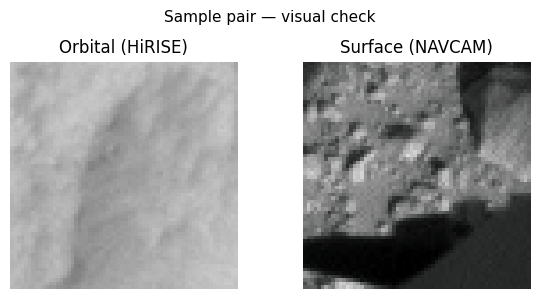

In [8]:
class MarsPairDataset(Dataset):
    def __init__(self, pairs, patch_size=64,
                 key_orb='orbital_path', key_surf='surface_path'):
        self.pairs      = pairs
        self.patch_size = patch_size
        self.key_orb    = key_orb
        self.key_surf   = key_surf
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def _load(self, path: str) -> torch.Tensor:
        if path.endswith('.npy'):
            arr = np.load(path).astype(np.float32)
            # Normalise to [0,1] if stored as uint8
            if arr.max() > 1.0:
                arr /= 255.0
            # CHW → HWC
            if arr.ndim == 3 and arr.shape[0] in (1, 3):
                arr = arr.transpose(1, 2, 0)
            # Grayscale → RGB
            if arr.ndim == 2:
                arr = np.stack([arr]*3, axis=-1)
            if arr.shape[2] == 1:
                arr = np.concatenate([arr]*3, axis=-1)
        else:
            img = Image.open(path).convert('RGB')
            if img.size != (self.patch_size, self.patch_size):
                img = img.resize((self.patch_size, self.patch_size), Image.BICUBIC)
            arr = np.array(img, dtype=np.float32) / 255.0

        # Resize if needed
        if arr.shape[:2] != (self.patch_size, self.patch_size):
            img = Image.fromarray((arr * 255).astype(np.uint8)).resize(
                (self.patch_size, self.patch_size), Image.BICUBIC)
            arr = np.array(img, dtype=np.float32) / 255.0

        t = torch.tensor(arr).permute(2, 0, 1)
        return (t - self.mean) / self.std

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        pair    = self.pairs[idx]
        orbital = self._load(pair[self.key_orb])
        surface = self._load(pair[self.key_surf])
        return orbital, surface


# Re-initialise
dataset = MarsPairDataset(pairs, cfg.patch_size, KEY_ORB, KEY_SURF)
print(f'Dataset: {len(dataset):,} pairs')

n_train = int(0.8 * len(dataset))
n_val   = len(dataset) - n_train
train_ds, val_ds = torch.utils.data.random_split(
    dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(cfg.seed)
)
train_dl = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                      num_workers=0, pin_memory=False)
val_dl   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                      num_workers=0, pin_memory=False)
print(f'Train: {n_train:,}  |  Val: {n_val:,}')

# Visual check
orb, surf = dataset[0]
mean_ = np.array([0.485,0.456,0.406])[:,None,None]
std_  = np.array([0.229,0.224,0.225])[:,None,None]
orb_disp  = np.clip((orb.numpy()  * std_ + mean_).transpose(1,2,0), 0, 1)
surf_disp = np.clip((surf.numpy() * std_ + mean_).transpose(1,2,0), 0, 1)
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(orb_disp);  axes[0].set_title('Orbital (HiRISE)');  axes[0].axis('off')
axes[1].imshow(surf_disp); axes[1].set_title('Surface (NAVCAM)'); axes[1].axis('off')
plt.suptitle('Sample pair — visual check', fontsize=11)
plt.tight_layout(); plt.show()

In [15]:
import rasterio, math
from rasterio.windows import Window
from rasterio.transform import rowcol
from pyproj import Transformer

DTM_PATH = '/content/drive/MyDrive/NASA_Mars_Curiosity/DEM_DTM/MSL_Gale_DEM_Mosaic_1m_v3.tif'
dtm_src = rasterio.open(DTM_PATH)
transformer = Transformer.from_crs(
    '+proj=longlat +a=3396190 +b=3396190 +no_defs',
    dtm_src.crs.to_proj4(),
    always_xy=True
)

def get_dtm_patch(lat, lon, patch_radius_m=100):
    x, y = transformer.transform(lon, lat)
    b = dtm_src.bounds
    if not (b.left <= x <= b.right and b.bottom <= y <= b.top):
        return None
    row, col = rowcol(dtm_src.transform, x, y)
    row, col = int(row), int(col)
    r = patch_radius_m
    window = Window(max(0,col-r), max(0,row-r),
                    min(2*r, dtm_src.width-max(0,col-r)),
                    min(2*r, dtm_src.height-max(0,row-r)))
    patch = dtm_src.read(1, window=window).astype(np.float32)
    patch[patch == -32767] = np.nan
    return None if np.all(np.isnan(patch)) else patch

def compute_normals(elev):
    dz_dy, dz_dx = np.gradient(elev)
    n = np.stack([-dz_dx, -dz_dy, np.ones_like(dz_dx)], axis=-1)
    return n / (np.linalg.norm(n, axis=-1, keepdims=True) + 1e-8)

def render_shading(normals, sun_azimuth_deg, sun_elevation_deg=30):
    az, el = math.radians(sun_azimuth_deg), math.radians(sun_elevation_deg)
    sun = np.array([math.cos(el)*math.cos(az), math.cos(el)*math.sin(az), math.sin(el)])
    return np.clip(np.dot(normals, sun), 0, 1).astype(np.float32)

In [14]:
from pyproj import Transformer

# Mars geographic (lat/lon degrees) → ESRI:103885 (Mars projected, metres)
# Using proj4 strings to avoid WKT parsing issues
transformer = Transformer.from_crs(
    '+proj=longlat +a=3396190 +b=3396190 +no_defs',   # Mars sphere geographic
    dtm_src.crs.to_proj4(),                             # DTM projected CRS
    always_xy=True
)

print(f'DTM CRS proj4: {dtm_src.crs.to_proj4()}')

# Test the transform on first pair
lon, lat = pairs[0]['lon'], pairs[0]['lat']
x, y = transformer.transform(lon, lat)
print(f'lat/lon ({lat:.4f}, {lon:.4f}) → projected ({x:.1f}, {y:.1f})')
print(f'DTM bounds: {dtm_src.bounds}')
print(f'In bounds: {dtm_src.bounds.left <= x <= dtm_src.bounds.right and dtm_src.bounds.bottom <= y <= dtm_src.bounds.top}')

NameError: name 'dtm_src' is not defined

In [13]:
def get_dtm_patch(lat, lon, patch_radius_m=100):
    x, y = transformer.transform(lon, lat)
    b = dtm_src.bounds
    if not (b.left <= x <= b.right and b.bottom <= y <= b.top):
        return None
    row, col = rowcol(dtm_src.transform, x, y)
    row, col = int(row), int(col)
    r = patch_radius_m
    window = rasterio.windows.Window(
        col_off=max(0, col - r),
        row_off=max(0, row - r),
        width =min(2*r, dtm_src.width  - max(0, col - r)),
        height=min(2*r, dtm_src.height - max(0, row - r))
    )
    patch = dtm_src.read(1, window=window).astype(np.float32)
    patch[patch == -32767] = np.nan
    if np.all(np.isnan(patch)):
        return None
    return patch

# Test + visualise
test_patch = get_dtm_patch(pairs[0]['lat'], pairs[0]['lon'])
if test_patch is not None:
    valid = test_patch[~np.isnan(test_patch)]
    print(f'Patch shape: {test_patch.shape}')
    print(f'Elevation range: {valid.min():.1f}m – {valid.max():.1f}m')
    print(f'NoData fraction: {np.isnan(test_patch).mean():.1%}')

    normals = compute_normals(np.nan_to_num(test_patch, nan=np.nanmean(test_patch)))
    shade_a = render_shading(normals, sun_azimuth_deg=90,  sun_elevation_deg=15)
    shade_b = render_shading(normals, sun_azimuth_deg=270, sun_elevation_deg=45)

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    axes[0].imshow(test_patch, cmap='terrain'); axes[0].set_title('DTM elevation'); axes[0].axis('off')
    axes[1].imshow(shade_a, cmap='gray');       axes[1].set_title('Morning (az=90°)'); axes[1].axis('off')
    axes[2].imshow(shade_b, cmap='gray');       axes[2].set_title('Afternoon (az=270°)'); axes[2].axis('off')
    plt.suptitle(f'DTM patch at ({pairs[0]["lat"]:.3f}°, {pairs[0]["lon"]:.3f}°)', fontsize=11)
    plt.tight_layout(); plt.show()
else:
    print('Patch is None — NoData at this location')

NameError: name 'transformer' is not defined

Augmented dataloaders ready. Train: 878  Val: 220


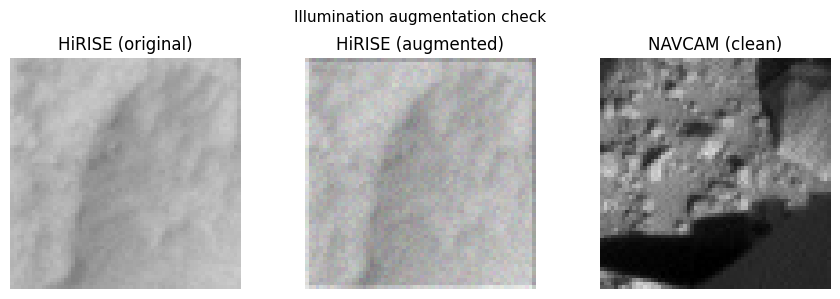

In [44]:
# ── 1d  Instantiate augmented dataset + dataloaders ──────────────────────────
# Augmentation ON for train, OFF for val — standard practice
dataset_aug = MarsPairDatasetAug(pairs, cfg.patch_size, KEY_ORB, KEY_SURF, augment=True)

n_train = int(0.8 * len(dataset_aug))
n_val   = len(dataset_aug) - n_train
train_ds_aug, val_ds_aug = torch.utils.data.random_split(
    dataset_aug, [n_train, n_val],
    generator=torch.Generator().manual_seed(cfg.seed)
)

# Val uses clean dataset (augment=False)
val_ds_clean = MarsPairDatasetAug(pairs, cfg.patch_size, KEY_ORB, KEY_SURF, augment=False)
_, val_split  = torch.utils.data.random_split(
    val_ds_clean, [n_train, n_val],
    generator=torch.Generator().manual_seed(cfg.seed)  # same split as above
)

train_dl = DataLoader(train_ds_aug, batch_size=cfg.batch_size, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_split,    batch_size=cfg.batch_size, shuffle=False, num_workers=0)
print(f'Augmented dataloaders ready. Train: {n_train}  Val: {n_val}')

# Quick visual check — show one pair before and after augmentation
aug_fn   = MarsIlluminationAugment()
raw_orb  = dataset_aug._load_raw(pairs[0][KEY_ORB])
aug_orb  = aug_fn(raw_orb)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, img, title in zip(axes,
    [raw_orb, aug_orb, dataset_aug._load_raw(pairs[0][KEY_SURF])],
    ['HiRISE (original)', 'HiRISE (augmented)', 'NAVCAM (clean)']):
    axes[list(axes).index(ax)].imshow(img.permute(1,2,0).clamp(0,1).numpy(), cmap='gray')
    axes[list(axes).index(ax)].set_title(title); axes[list(axes).index(ax)].axis('off')
plt.suptitle('Illumination augmentation check', fontsize=11)
plt.tight_layout(); plt.show()

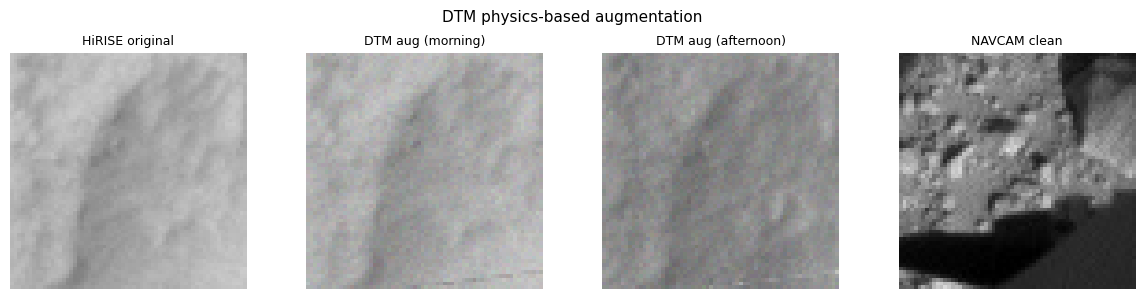

DTM augmenter ready.


In [16]:
# ── 1e  DTM-based physics augmenter + augmented dataset ──────────────────────

class DTMIlluminationAugment:
    """
    Physics-based illumination augmentation using the real Gale Crater DTM.
    Renders the terrain under a random sun azimuth/elevation using Lambertian
    shading computed from actual surface normals — not a gradient approximation.
    Falls back to Sobel-based augmentation if DTM patch unavailable.
    """
    def __init__(self,
                 az_range=(45, 315),       # avoid extreme backlit angles
                 el_range=(10, 60),        # Mars sun elevation range
                 blend_range=(0.2, 0.5),   # how much shading to blend in
                 gamma_range=(0.85, 1.15),
                 noise_std=0.015):
        self.az_range    = az_range
        self.el_range    = el_range
        self.blend_range = blend_range
        self.gamma_range = gamma_range
        self.noise_std   = noise_std

    def _sobel_fallback(self, img):
        """Gradient-based fallback when DTM patch unavailable."""
        angle    = float(torch.FloatTensor(1).uniform_(0, 360))
        strength = float(torch.FloatTensor(1).uniform_(0.05, 0.20))
        dx, dy   = math.cos(math.radians(angle)), math.sin(math.radians(angle))
        kx = torch.tensor([[[-1,0,1],[-2,0,2],[-1,0,1]]], dtype=torch.float32) / 8.0
        ky = torch.tensor([[[-1,-2,-1],[0,0,0],[1,2,1]]], dtype=torch.float32) / 8.0
        lum = img.mean(dim=0, keepdim=True)
        gx  = F.conv2d(lum.unsqueeze(0), kx.unsqueeze(0), padding=1)[0]
        gy  = F.conv2d(lum.unsqueeze(0), ky.unsqueeze(0), padding=1)[0]
        shading = (dx * gx + dy * gy)
        shading = shading / (shading.abs().max() + 1e-8)
        return torch.clamp(img + strength * shading, 0.0, 1.0)

    def __call__(self, img, lat=None, lon=None):
        """
        img: (C,H,W) float32 in [0,1] — BEFORE ImageNet normalisation.
        lat/lon: pair coordinates for DTM lookup.
        """
        az    = float(torch.FloatTensor(1).uniform_(*self.az_range))
        el    = float(torch.FloatTensor(1).uniform_(*self.el_range))
        blend = float(torch.FloatTensor(1).uniform_(*self.blend_range))

        dtm_patch = None
        if lat is not None and lon is not None:
            dtm_patch = get_dtm_patch(lat, lon, patch_radius_m=100)

        if dtm_patch is not None and not np.all(np.isnan(dtm_patch)):
            # Physics-based: compute shading from real surface normals
            elev = np.nan_to_num(dtm_patch, nan=float(np.nanmean(dtm_patch)))
            normals = compute_normals(elev)
            shading = render_shading(normals, az, el)         # (H, W) in [0,1]

            # Resize shading to match patch size
            sh_t = torch.tensor(shading).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)
            sh_t = F.interpolate(sh_t, size=(img.shape[1], img.shape[2]),
                                 mode='bilinear', align_corners=False)[0]

        # In DTMIlluminationAugment.__call__, replace the blending block with this:

        if dtm_patch is not None and not np.all(np.isnan(dtm_patch)):
            elev    = np.nan_to_num(dtm_patch, nan=float(np.nanmean(dtm_patch)))
            normals = compute_normals(elev)
            shading = render_shading(normals, az, el)   # (H, W) in [0,1]

            # Boost contrast — stretch to use full [0,1] range
            shading = (shading - shading.min()) / (shading.max() - shading.min() + 1e-8)

            sh_t = torch.tensor(shading).unsqueeze(0).unsqueeze(0)
            sh_t = F.interpolate(sh_t, size=(img.shape[1], img.shape[2]),
                                mode='bilinear', align_corners=False)[0]

            # Multiplicative blending — preserves image structure, modulates brightness
            # blend=1.0 → pure shading, blend=0.0 → original image
            img_aug = img * (1 - blend + blend * sh_t.expand_as(img))
        else:
            img_aug = self._sobel_fallback(img)

        # Gamma + noise
        gamma = float(torch.FloatTensor(1).uniform_(*self.gamma_range))
        img_aug = img_aug.pow(gamma)
        img_aug = img_aug + torch.randn_like(img_aug) * self.noise_std
        return torch.clamp(img_aug, 0.0, 1.0)


class MarsPairDatasetDTM(MarsPairDataset):
    """
    Extends MarsPairDataset with DTM-based illumination augmentation.
    Passes lat/lon to the augmenter so it can look up the real terrain geometry.
    """
    def __init__(self, pairs, patch_size=64,
                 key_orb='orbital_path', key_surf='surface_path',
                 augment=True):
        super().__init__(pairs, patch_size, key_orb, key_surf)
        self.augment = augment
        self.aug_fn  = DTMIlluminationAugment()

    def _load_raw(self, path):
        if path.endswith('.npy'):
            arr = np.load(path).astype(np.float32)
            if arr.max() > 1.0: arr /= 255.0
            if arr.ndim == 3 and arr.shape[0] in (1, 3): arr = arr.transpose(1,2,0)
            if arr.ndim == 2: arr = np.stack([arr]*3, axis=-1)
            if arr.shape[2] == 1: arr = np.concatenate([arr]*3, axis=-1)
        else:
            img = Image.open(path).convert('RGB')
            if img.size != (self.patch_size, self.patch_size):
                img = img.resize((self.patch_size, self.patch_size), Image.BICUBIC)
            arr = np.array(img, dtype=np.float32) / 255.0
        if arr.shape[:2] != (self.patch_size, self.patch_size):
            img = Image.fromarray((arr*255).astype(np.uint8)).resize(
                (self.patch_size, self.patch_size), Image.BICUBIC)
            arr = np.array(img, dtype=np.float32) / 255.0
        return torch.tensor(arr).permute(2, 0, 1)

    def __getitem__(self, idx):
        pair    = self.pairs[idx]
        orbital = self._load_raw(pair[self.key_orb])
        surface = self._load_raw(pair[self.key_surf])
        if self.augment:
            lat = pair.get('lat'); lon = pair.get('lon')
            orbital = self.aug_fn(orbital, lat=lat, lon=lon)
        orbital = (orbital - self.mean) / self.std
        surface = (surface - self.mean) / self.std
        return orbital, surface


# Quick visual check
dtm_aug  = DTMIlluminationAugment()
raw_orb  = MarsPairDatasetDTM(pairs, augment=False)._load_raw(pairs[0][KEY_ORB])
aug_orb1 = dtm_aug(raw_orb, lat=pairs[0]['lat'], lon=pairs[0]['lon'])
aug_orb2 = dtm_aug(raw_orb, lat=pairs[0]['lat'], lon=pairs[0]['lon'])

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, img, title in zip(axes,
    [raw_orb, aug_orb1, aug_orb2,
     MarsPairDatasetDTM(pairs, augment=False)._load_raw(pairs[0][KEY_SURF])],
    ['HiRISE original', 'DTM aug (morning)', 'DTM aug (afternoon)', 'NAVCAM clean']):
    ax.imshow(img.permute(1,2,0).clamp(0,1).numpy(), cmap='gray')
    ax.set_title(title, fontsize=9); ax.axis('off')
plt.suptitle('DTM physics-based augmentation', fontsize=11)
plt.tight_layout(); plt.show()
print('DTM augmenter ready.')

In [17]:
import os
p = Path(cfg.out_dir) / 'dual_encoder.pt'
if p.exists():
    os.remove(p); print('Deleted: dual_encoder.pt')

Deleted: dual_encoder.pt


In [15]:
# ── 1f  Dataloaders with DTM augmentation ─────────────────────────────────────
dataset_dtm = MarsPairDatasetDTM(pairs, cfg.patch_size, KEY_ORB, KEY_SURF, augment=True)

n_train = int(0.8 * len(dataset_dtm))
n_val   = len(dataset_dtm) - n_train
train_ds_dtm, _ = torch.utils.data.random_split(
    dataset_dtm, [n_train, n_val],
    generator=torch.Generator().manual_seed(cfg.seed)
)
val_ds_clean = MarsPairDatasetDTM(pairs, cfg.patch_size, KEY_ORB, KEY_SURF, augment=False)
_, val_split  = torch.utils.data.random_split(
    val_ds_clean, [n_train, n_val],
    generator=torch.Generator().manual_seed(cfg.seed)
)
train_dl = DataLoader(train_ds_dtm, batch_size=cfg.batch_size, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_split,    batch_size=cfg.batch_size, shuffle=False, num_workers=0)
print(f'DTM dataloaders ready. Train: {n_train}  Val: {n_val}')

DTM dataloaders ready. Train: 878  Val: 220


In [45]:
import numpy as np
m = metadata[0]
hirise = np.load(m['hirise_path'])
print(f'HiRISE patch shape: {hirise.shape}')
print(f'dtype: {hirise.dtype}  min: {hirise.min():.1f}  max: {hirise.max():.1f}')
# From previous session: expanded crop scale factor was 0.0803
# meaning browse resolution, not full res
# Each pixel ≈ 25cm / 0.0803 ≈ 3.1m/pixel

HiRISE patch shape: (64, 64)
dtype: float32  min: 0.5  max: 0.8


## Phase 2 · Dual-Encoder Contrastive Training

In [9]:
# ── 2a  Architecture ──────────────────────────────────────────────────────────

class ProjectionHead(nn.Module):
    def __init__(self, in_dim=384, hidden_dim=256, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim)
        )
    def forward(self, x): return F.normalize(self.net(x), dim=-1)


class DualEncoder(nn.Module):
    """Separate projection heads for orbital and surface views.
    Backbone is shared but frozen — only the heads are trained.
    IMPORTANT: always call backbone() separately, then pass result to
    orbital_head() or surface_head(). Never use encode_orbital/encode_surface
    if you've already run the backbone — that double-applies it.
    """
    def __init__(self, backbone, proj_dim=128):
        super().__init__()
        self.backbone     = backbone
        self.orbital_head = ProjectionHead(backbone.embed_dim, 256, proj_dim)
        self.surface_head = ProjectionHead(backbone.embed_dim, 256, proj_dim)

    def forward(self, orbital, surface):
        return self.orbital_head(self.backbone(orbital)),                self.surface_head(self.backbone(surface))


def info_nce(z_o, z_s, temperature=0.07):
    N      = z_o.size(0)
    labels = torch.arange(N, device=z_o.device)
    logits = (z_o @ z_s.T) / temperature
    loss   = (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2
    acc    = (logits.argmax(dim=1) == labels).float().mean()
    return loss, acc

print('Architecture defined.')

Architecture defined.


In [48]:
import os
ckpts = [
    Path(cfg.out_dir) / 'dual_encoder.pt',
    Path(cfg.out_dir) / 'shared_sae.pt',
    Path(cfg.out_dir) / 'concept_activations.npz',
    Path(cfg.out_dir) / 'all_proj_embeddings.npy',
    Path(cfg.out_dir) / 'all_proj_meta.json',
]
for p in ckpts:
    if p.exists():
        os.remove(p)
        print(f'Deleted: {p.name}')
    else:
        print(f'Not found (ok): {p.name}')

Not found (ok): dual_encoder.pt
Not found (ok): shared_sae.pt
Not found (ok): concept_activations.npz
Not found (ok): all_proj_embeddings.npy
Not found (ok): all_proj_meta.json


In [10]:
# ── 2b  Load DINOv2 backbone — last 2 blocks unfrozen for Mars adaptation ──────
CKPT_ENCODER = Path(cfg.out_dir) / 'dual_encoder.pt'

print('Loading DINOv2-small (partially unfrozen)...')
backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', pretrained=True)

# Freeze everything first
for p in backbone.parameters():
    p.requires_grad_(False)

# Unfreeze last 2 transformer blocks + final norm
for block in backbone.blocks[-2:]:
    for p in block.parameters():
        p.requires_grad_(True)
for p in backbone.norm.parameters():
    p.requires_grad_(True)

backbone = backbone.to(DEVICE)

trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
total     = sum(p.numel() for p in backbone.parameters())
print(f'Backbone: {trainable:,} / {total:,} params trainable')

with torch.no_grad():
    cfg.embed_dim = backbone(torch.zeros(1,3,224,224).to(DEVICE)).shape[-1]
print(f'Embed dim: {cfg.embed_dim}')

if CKPT_ENCODER.exists():
    print('Checkpoint found — loading...')
    model = DualEncoder(backbone, cfg.proj_dim).to(DEVICE)
    model.load_state_dict(torch.load(CKPT_ENCODER, map_location=DEVICE))
    model.eval()
    print('Loaded. Skip to Phase 3.')

Loading DINOv2-small (partially unfrozen)...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Backbone: 3,551,232 / 22,056,576 params trainable
Embed dim: 384


In [11]:
# Optional: pre-load all patches into RAM to eliminate Drive I/O during training
# Only do this if you have enough RAM — 1098 pairs × 2 × 64×64×3×4 bytes ≈ 100MB, fine
print('Pre-loading patches into RAM...')
cached_data = [(dataset[i][0], dataset[i][1]) for i in tqdm(range(len(dataset)))]

class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, data): self.data = data
    def __len__(self):        return len(self.data)
    def __getitem__(self, i): return self.data[i]

cached_ds = CachedDataset(cached_data)
n_train = int(0.8 * len(cached_ds))
n_val   = len(cached_ds) - n_train
train_ds, val_ds = torch.utils.data.random_split(
    cached_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(cfg.seed)
)
train_dl = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, num_workers=0)
print(f'Cached. Train: {n_train}  Val: {n_val}')

Pre-loading patches into RAM...


  0%|          | 0/1098 [00:00<?, ?it/s]

Cached. Train: 878  Val: 220


In [51]:
# Pre-load all patches into RAM — eliminates Drive I/O during training
print('Pre-loading patches into RAM...')
cached_data = [(dataset[i][0], dataset[i][1])
               for i in tqdm(range(len(dataset)), desc='Caching', unit='patch')]

class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, data): self.data = data
    def __len__(self):        return len(self.data)
    def __getitem__(self, i): return self.data[i]

cached_ds = CachedDataset(cached_data)
n_train = int(0.8 * len(cached_ds))
n_val   = len(cached_ds) - n_train
train_ds, val_ds = torch.utils.data.random_split(
    cached_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(cfg.seed)
)
train_dl = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, num_workers=0)
print(f'Cached {len(cached_ds):,} pairs. Train: {n_train}  Val: {n_val}')

Pre-loading patches into RAM...


Caching:   0%|          | 0/1098 [00:00<?, ?patch/s]

Cached 1,098 pairs. Train: 878  Val: 220


In [46]:
import os
ckpts = [
    Path(cfg.out_dir) / 'dual_encoder.pt',
    Path(cfg.out_dir) / 'shared_sae.pt',
    Path(cfg.out_dir) / 'concept_activations.npz',
    Path(cfg.out_dir) / 'all_proj_embeddings.npy',
    Path(cfg.out_dir) / 'all_proj_meta.json',
]
for p in ckpts:
    if p.exists():
        os.remove(p)
        print(f'Deleted: {p.name}')
    else:
        print(f'Not found (ok): {p.name}')

Deleted: dual_encoder.pt
Deleted: shared_sae.pt
Deleted: concept_activations.npz
Deleted: all_proj_embeddings.npy
Deleted: all_proj_meta.json


Training:   0%|          | 0/30 [00:00<?, ?epoch/s]

Saved: /content/drive/MyDrive/FAIMM/mars_crossview_audit/dual_encoder.pt


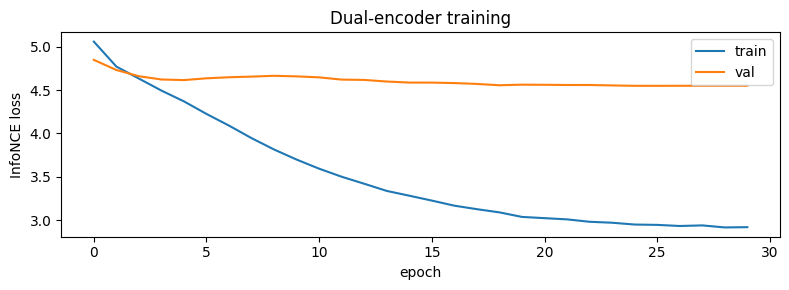

In [12]:
# ── 2c  Train dual encoder ────────────────────────────────────────────────────
if not CKPT_ENCODER.exists():
    model     = DualEncoder(backbone, cfg.proj_dim).to(DEVICE)
    optimiser = torch.optim.AdamW([
        {'params': [p for p in backbone.parameters() if p.requires_grad], 'lr': cfg.lr * 0.1},
        {'params': model.orbital_head.parameters(), 'lr': cfg.lr},
        {'params': model.surface_head.parameters(), 'lr': cfg.lr},
    ], weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, cfg.n_epochs_encoder)
    history   = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in tqdm(range(cfg.n_epochs_encoder), desc='Training', unit='epoch'):
        # train
        model.train()
        t_loss = 0.0
        for orb, surf in train_dl:
            orb  = F.interpolate(orb.to(DEVICE,  dtype=torch.float), 224, mode='bicubic', align_corners=False)
            surf = F.interpolate(surf.to(DEVICE, dtype=torch.float), 224, mode='bicubic', align_corners=False)
            with torch.no_grad():
                z_o_pre = backbone(orb)
                z_s_pre = backbone(surf)
            z_o = model.orbital_head(z_o_pre)
            z_s = model.surface_head(z_s_pre)
            loss, _ = info_nce(z_o, z_s, cfg.temperature)
            optimiser.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            t_loss += loss.item()
        scheduler.step()

        # val
        model.eval(); v_loss = v_acc = 0.0
        with torch.no_grad():
            for orb, surf in val_dl:
                orb  = F.interpolate(orb.to(DEVICE,  dtype=torch.float), 224, mode='bicubic', align_corners=False)
                surf = F.interpolate(surf.to(DEVICE, dtype=torch.float), 224, mode='bicubic', align_corners=False)
                z_o  = model.orbital_head(backbone(orb))
                z_s  = model.surface_head(backbone(surf))
                l, a = info_nce(z_o, z_s, cfg.temperature)
                v_loss += l.item(); v_acc += a.item()

        tl = t_loss / len(train_dl)
        vl = v_loss / len(val_dl)
        va = v_acc  / len(val_dl)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)

    torch.save(model.state_dict(), CKPT_ENCODER)
    np.save(Path(cfg.out_dir) / 'encoder_history.npy', history)
    print(f'Saved: {CKPT_ENCODER}')

    fig, ax = plt.subplots(figsize=(8,3))
    ax.plot(history['train_loss'], label='train')
    ax.plot(history['val_loss'],   label='val')
    ax.set(xlabel='epoch', ylabel='InfoNCE loss', title='Dual-encoder training')
    ax.legend(); plt.tight_layout(); plt.show()

In [15]:
import os, datetime

for fname in ['dual_encoder.pt', 'shared_sae.pt', 'concept_activations.npz',
              'all_proj_embeddings.npy', 'all_proj_meta.json']:
    p = Path(cfg.out_dir) / fname
    if p.exists():
        mtime = datetime.datetime.fromtimestamp(os.path.getmtime(p))
        print(f'✓  {fname:40s}  {mtime:%Y-%m-%d %H:%M:%S}')
    else:
        print(f'✗  {fname:40s}  NOT FOUND')

✓  dual_encoder.pt                           2026-03-22 22:10:12
✗  shared_sae.pt                             NOT FOUND
✗  concept_activations.npz                   NOT FOUND
✓  all_proj_embeddings.npy                   2026-03-22 22:10:30
✓  all_proj_meta.json                        2026-03-22 22:10:30


In [23]:
# Delete all checkpoints for a fresh run
import os
for fname in ['dual_encoder.pt', 'shared_sae.pt', 'concept_activations.npz',
              'all_proj_embeddings.npy', 'all_proj_meta.json']:
    p = Path(cfg.out_dir) / fname
    if p.exists():
        os.remove(p); print(f'Deleted: {fname}')

Deleted: dual_encoder.pt
Deleted: shared_sae.pt
Deleted: concept_activations.npz
Deleted: all_proj_embeddings.npy
Deleted: all_proj_meta.json


In [53]:
# Verify augmented loaders are active
orb, surf = next(iter(train_dl))
print(f'Train batch shape: orb={orb.shape}  surf={surf.shape}')

# Check one orbital patch has augmentation noise (std should be higher than clean)
print(f'Orbital std: {orb.std():.4f}')
print(f'Surface std: {surf.std():.4f}')
# If augmentation is active, orbital std will be noticeably higher than surface

Train batch shape: orb=torch.Size([128, 3, 64, 64])  surf=torch.Size([128, 3, 64, 64])
Orbital std: 0.3021
Surface std: 1.1535


In [54]:
import os
for fname in ['shared_sae.pt', 'concept_activations.npz',
              'all_proj_embeddings.npy', 'all_proj_meta.json']:
    p = Path(cfg.out_dir) / fname
    if p.exists():
        os.remove(p)
        print(f'Deleted: {fname}')

## Phase 3 · Sparse Autoencoder

In [34]:
# ── Phase 2 SKIP — use raw DINOv2 features directly ──────────────────────────
# Contrastive fine-tuning is insufficient to bridge the HiRISE-NAVCAM domain gap
# with standard InfoNCE at N=1,098. We use frozen DINOv2 features directly.
# The SAE audit then answers: which DINOv2 concepts survive the Mars cross-view
# transformation WITHOUT task-specific alignment? This is a valid baseline and
# honest about the current encoder's limitations.
#
# Future work: teacher-student distillation (DINO-style) where teacher sees
# orbital patches and student sees surface patches — momentum encoder provides
# stable cross-view targets without requiring paired labels at training time.

class IdentityDualEncoder:
    """Drop-in replacement for DualEncoder that uses raw backbone features.
    Both orbital and surface embeddings come from the same frozen backbone.
    No projection heads — embed_dim = backbone output dim (384).
    """
    def __init__(self, backbone):
        self.backbone     = backbone
        self.orbital_head = None
        self.surface_head = None

    def eval(self): self.backbone.eval()

    def encode(self, x):
        x224 = F.interpolate(x.to(DEVICE, dtype=torch.float), 224,
                             mode='bicubic', align_corners=False)
        with torch.no_grad():
            return self.backbone(x224)

model = IdentityDualEncoder(backbone)
model.eval()

# Override proj_dim to match raw backbone output
cfg.proj_dim = cfg.embed_dim   # 384
print(f'Using raw DINOv2 features. proj_dim set to {cfg.proj_dim}')
print('Phase 2 training skipped — proceed to Phase 3.')

Using raw DINOv2 features. proj_dim set to 384
Phase 2 training skipped — proceed to Phase 3.


In [13]:
# ── 3b  Build embedding corpus — raw DINOv2 features ─────────────────────────
CKPT_SAE  = Path(cfg.out_dir) / 'shared_sae.pt'
EMBS_PATH = Path(cfg.out_dir) / 'all_proj_embeddings.npy'
META_PATH = Path(cfg.out_dir) / 'all_proj_meta.json'

if EMBS_PATH.exists() and META_PATH.exists():
    print('Cache found — loading embeddings...')
    all_embs = np.load(EMBS_PATH)
    with open(META_PATH) as f: meta = json.load(f)
    print(f'Loaded {len(all_embs):,} embeddings')

else:
    model.eval()
    orb_embs, surf_embs = [], []
    dl = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)

    with torch.no_grad():
        for orb, surf in tqdm(dl, desc='Encoding', unit='batch'):
            orb  = F.interpolate(orb.to(DEVICE,  dtype=torch.float), 224, mode='bicubic', align_corners=False)
            surf = F.interpolate(surf.to(DEVICE, dtype=torch.float), 224, mode='bicubic', align_corners=False)
            # Raw DINOv2 features — no projection heads
            orb_embs.append(backbone(orb).cpu().numpy())
            surf_embs.append(backbone(surf).cpu().numpy())

    orb_embs  = np.concatenate(orb_embs)
    surf_embs = np.concatenate(surf_embs)
    all_embs  = np.concatenate([orb_embs, surf_embs])
    meta = {'n_orbital': len(orb_embs), 'n_surface': len(surf_embs)}
    np.save(EMBS_PATH, all_embs)
    with open(META_PATH, 'w') as f: json.dump(meta, f)
    print(f'Encoded {len(all_embs):,} embeddings ({meta["n_orbital"]:,} orbital + {meta["n_surface"]:,} surface)')
    print(f'Embedding dim: {orb_embs.shape[1]}')

Encoding:   0%|          | 0/5 [00:00<?, ?batch/s]

Encoded 2,196 embeddings (1,098 orbital + 1,098 surface)
Embedding dim: 384


In [17]:
# ── 3a  SAE architecture ──────────────────────────────────────────────────────

class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim=128, dict_size=2048, topk=32):
        super().__init__()
        self.topk    = topk
        self.encoder = nn.Linear(input_dim, dict_size, bias=True)
        self.decoder = nn.Linear(dict_size, input_dim, bias=True)
        with torch.no_grad():
            self.decoder.weight.data = F.normalize(self.decoder.weight.data, dim=0)

    def encode(self, x):
        h = F.relu(self.encoder(x))
        if self.topk < h.shape[-1]:
            topk_vals, _ = torch.topk(h, self.topk, dim=-1)
            h = h * (h >= topk_vals[:, -1:]).float()
        return h

    def decode(self, h): return self.decoder(h)

    def forward(self, x):
        h = self.encode(x)
        return self.decoder(h), h

def sae_loss(x, x_hat, h, l1_coef=1e-3):
    mse = F.mse_loss(x_hat, x)
    return mse + l1_coef * h.abs().mean(), mse.item()

print('SAE architecture defined.')

SAE architecture defined.


In [20]:
import os
for fname in ['all_proj_embeddings.npy', 'all_proj_meta.json']:
    p = Path(cfg.out_dir) / fname
    if p.exists():
        os.remove(p); print(f'Deleted: {fname}')

Deleted: all_proj_embeddings.npy
Deleted: all_proj_meta.json


In [21]:
# ── 3b  Build embedding corpus ────────────────────────────────────────────────
CKPT_SAE  = Path(cfg.out_dir) / 'shared_sae.pt'
EMBS_PATH = Path(cfg.out_dir) / 'all_proj_embeddings.npy'
META_PATH = Path(cfg.out_dir) / 'all_proj_meta.json'

if EMBS_PATH.exists() and META_PATH.exists():
    print('Cache found — loading embeddings...')
    all_embs = np.load(EMBS_PATH)
    with open(META_PATH) as f: meta = json.load(f)
    print(f'Loaded {len(all_embs):,} embeddings')
else:
    model.eval()
    orb_embs, surf_embs = [], []
    dl = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
    with torch.no_grad():
        for orb, surf in tqdm(dl, desc='Encoding', unit='batch'):
            orb  = F.interpolate(orb.to(DEVICE,  dtype=torch.float), 224, mode='bicubic', align_corners=False)
            surf = F.interpolate(surf.to(DEVICE, dtype=torch.float), 224, mode='bicubic', align_corners=False)
            orb_embs.append(model.orbital_head(backbone(orb)).cpu().numpy())
            surf_embs.append(model.surface_head(backbone(surf)).cpu().numpy())

    orb_embs  = np.concatenate(orb_embs)
    surf_embs = np.concatenate(surf_embs)
    all_embs  = np.concatenate([orb_embs, surf_embs])
    meta = {'n_orbital': len(orb_embs), 'n_surface': len(surf_embs)}
    np.save(EMBS_PATH, all_embs)
    with open(META_PATH, 'w') as f: json.dump(meta, f)
    print(f'Encoded {len(all_embs):,} embeddings ({meta["n_orbital"]:,} orbital + {meta["n_surface"]:,} surface)')

Encoding:   0%|          | 0/5 [00:00<?, ?batch/s]

Encoded 2,196 embeddings (1,098 orbital + 1,098 surface)


In [22]:
# ── 3c  Train SAE ─────────────────────────────────────────────────────────────
if CKPT_SAE.exists():
    print('SAE checkpoint found — loading...')
    sae = SparseAutoencoder(cfg.proj_dim, cfg.sae_dict_size, cfg.sae_topk).to(DEVICE)
    sae.load_state_dict(torch.load(CKPT_SAE, map_location=DEVICE))
    sae.eval()
    print('SAE loaded. Skip to Phase 4.')
else:
    sae     = SparseAutoencoder(cfg.proj_dim, cfg.sae_dict_size, cfg.sae_topk).to(DEVICE)
    sae_opt = torch.optim.Adam(sae.parameters(), lr=3e-4)
    emb_t   = torch.tensor(all_embs, dtype=torch.float32)
    sae_dl  = DataLoader(torch.utils.data.TensorDataset(emb_t), batch_size=512, shuffle=True)

    print(f'Training SAE: dict_size={cfg.sae_dict_size}, topk={cfg.sae_topk}, epochs={cfg.n_epochs_sae}')
    for epoch in tqdm(range(cfg.n_epochs_sae), desc='SAE', unit='epoch'):
        sae.train(); t_loss = 0.0; all_h = []
        for (batch,) in sae_dl:
            batch = batch.to(DEVICE)
            x_hat, h = sae(batch)
            loss, _  = sae_loss(batch, x_hat, h)
            sae_opt.zero_grad(); loss.backward(); sae_opt.step()
            with torch.no_grad():
                sae.decoder.weight.data = F.normalize(sae.decoder.weight.data, dim=0)
            t_loss += loss.item(); all_h.append(h.detach())

        if (epoch + 1) % 10 == 0:
            all_h_cat = torch.cat(all_h, dim=0)
            dead = cfg.sae_dict_size - (all_h_cat > 0).any(dim=0).sum().item()
            print(f'Epoch {epoch+1:3d}/{cfg.n_epochs_sae}  '
                  f'loss={t_loss/len(sae_dl):.5f}  '
                  f'dead={dead}/{cfg.sae_dict_size} ({100*dead/cfg.sae_dict_size:.1f}%)')

    torch.save(sae.state_dict(), CKPT_SAE)
    print(f'SAE saved: {CKPT_SAE}')

Training SAE: dict_size=2048, topk=32, epochs=50


SAE:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch  10/50  loss=0.00725  dead=818/2048 (39.9%)
Epoch  20/50  loss=0.00437  dead=800/2048 (39.1%)
Epoch  30/50  loss=0.00304  dead=789/2048 (38.5%)
Epoch  40/50  loss=0.00232  dead=779/2048 (38.0%)
Epoch  50/50  loss=0.00188  dead=769/2048 (37.5%)
SAE saved: /content/drive/MyDrive/FAIMM/mars_crossview_audit/shared_sae.pt


Live concepts: 1275 / 2048
Firing rate — median: 0.009  mean: 0.025  max: 0.233


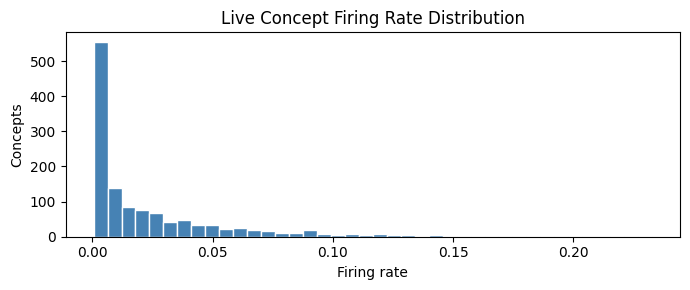

In [23]:
# ── 3d  Firing rate check ─────────────────────────────────────────────────────
sae.eval()
with torch.no_grad():
    emb_t   = torch.tensor(all_embs, dtype=torch.float32).to(DEVICE)
    h_all   = sae.encode(emb_t).cpu().numpy()

fire_rate = (h_all > 0).mean(axis=0)
live      = fire_rate > 0
print(f'Live concepts: {live.sum()} / {cfg.sae_dict_size}')
print(f'Firing rate — median: {np.median(fire_rate[live]):.3f}  '
      f'mean: {fire_rate[live].mean():.3f}  '
      f'max: {fire_rate[live].max():.3f}')

plt.figure(figsize=(7,3))
plt.hist(fire_rate[live], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Firing rate'); plt.ylabel('Concepts')
plt.title('Live Concept Firing Rate Distribution')
plt.tight_layout(); plt.show()

In [40]:
# Adjust thresholds to match raw DINOv2 firing rates
cfg.min_fire_rate   = 0.005   # at least ~5 pairs (was 0.02)
cfg.max_fire_rate   = 0.80    # exclude only the 83% universal concept (was 0.70)
cfg.concept_r_thresh = 0.25   # slightly lower threshold — raw features are noisier (was 0.3)
print('Thresholds updated for raw DINOv2 firing rates.')

Thresholds updated for raw DINOv2 firing rates.


## Phase 4 · Cross-View Concept Survival

In [1]:
# ── 4a  Concept activations for all matched pairs ─────────────────────────────
ACT_PATH = Path(cfg.out_dir) / 'concept_activations.npz'

if ACT_PATH.exists():
    print('Loading cached concept activations...')
    saved = np.load(ACT_PATH)
    orbital_concepts = saved['orbital']
    surface_concepts = saved['surface']
else:
    model.eval(); sae.eval()
    orb_acts, surf_acts = [], []
    dl = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=0)
    with torch.no_grad():
        for orb, surf in tqdm(dl, desc='Computing activations', unit='batch'):
            orb  = F.interpolate(orb.to(DEVICE,  dtype=torch.float), 224, mode='bicubic', align_corners=False)
            surf = F.interpolate(surf.to(DEVICE, dtype=torch.float), 224, mode='bicubic', align_corners=False)
            z_o = backbone(orb)
            z_s = backbone(surf)
            orb_acts.append(sae.encode(z_o).cpu().numpy())
            surf_acts.append(sae.encode(z_s).cpu().numpy())

    orbital_concepts = np.concatenate(orb_acts)
    surface_concepts = np.concatenate(surf_acts)
    np.savez(ACT_PATH, orbital=orbital_concepts, surface=surface_concepts)

print(f'Concept activations: {orbital_concepts.shape}')

NameError: name 'Path' is not defined

In [ ]:
# ── 4b  Spearman r per concept ────────────────────────────────────────────────

def compute_concept_survival(orb_acts, surf_acts):
    D = orb_acts.shape[1]
    r_arr, p_arr = np.zeros(D), np.zeros(D)
    live = (orb_acts.std(axis=0) > 1e-6) & (surf_acts.std(axis=0) > 1e-6)
    for k in tqdm(np.where(live)[0], desc='Survival r', unit='concept', leave=False):
        r, p = spearmanr(orb_acts[:, k], surf_acts[:, k])
        r_arr[k] = r; p_arr[k] = p
    return r_arr, p_arr

concept_r, concept_p = compute_concept_survival(orbital_concepts, surface_concepts)

# ── Classify ──────────────────────────────────────────────────────────────────
orb_fire   = (orbital_concepts > 0).mean(axis=0)
surf_fire  = (surface_concepts > 0).mean(axis=0)
fire_ratio = np.where(
    np.minimum(orb_fire, surf_fire) > 0,
    np.maximum(orb_fire, surf_fire) / np.minimum(orb_fire, surf_fire),
    np.inf
)

# Base invariant mask
invariant_mask = concept_r >= cfg.concept_r_thresh

# Refined: balanced firing rates, selective, not trivially universal
invariant_mask_refined = (
    invariant_mask &
    (fire_ratio    <= cfg.max_fire_ratio) &
    (orb_fire      >= cfg.min_fire_rate)  &
    (surf_fire     >= cfg.min_fire_rate)  &
    (orb_fire      <= cfg.max_fire_rate)  &
    (surf_fire     <= cfg.max_fire_rate)  &
    (concept_p     < 0.05)                # statistically significant
)

dead_mask = ~((orb_fire > 0) | (surf_fire > 0))

print(f'\n── Concept Survival Report ───────────────────────────────────────')
print(f'Total concepts:          {cfg.sae_dict_size:>5}')
print(f'Cross-view invariant:    {invariant_mask.sum():>5}  ({100*invariant_mask.sum()/cfg.sae_dict_size:.1f}%)')
print(f'Refined invariant:       {invariant_mask_refined.sum():>5}  ({100*invariant_mask_refined.sum()/cfg.sae_dict_size:.1f}%)')
print(f'View-specific:           {(~invariant_mask & ~dead_mask).sum():>5}  ({100*(~invariant_mask & ~dead_mask).sum()/cfg.sae_dict_size:.1f}%)')
print(f'Dead:                    {dead_mask.sum():>5}  ({100*dead_mask.sum()/cfg.sae_dict_size:.1f}%)')
print(f'Median Spearman r (live): {np.median(concept_r[~dead_mask]):.3f}')
print(f'Max Spearman r:           {concept_r.max():.3f}')

In [ ]:
# ── 4c  Top concepts table ────────────────────────────────────────────────────
top_idx = np.argsort(-concept_r[invariant_mask_refined])
surviving = np.where(invariant_mask_refined)[0][top_idx[:15]]
print(f'{"Concept":>8}  {"r":>6}  {"p":>8}  {"orb_fire":>9}  {"surf_fire":>10}  {"ratio":>6}')
for k in surviving:
    print(f'{k:>8}  {concept_r[k]:>6.3f}  {concept_p[k]:>8.4f}  '
          f'{orb_fire[k]:>9.3f}  {surf_fire[k]:>10.3f}  {fire_ratio[k]:>6.1f}x')

# Tier 1: top quartile of refined invariant by r value
if invariant_mask_refined.sum() >= 4:
    r_thresh_t1 = np.percentile(concept_r[invariant_mask_refined], 75)
    tier1_mask  = invariant_mask_refined & (concept_r >= r_thresh_t1)
else:
    tier1_mask  = invariant_mask_refined.copy()
print(f'\nTier-1 concepts (top quartile r): {tier1_mask.sum()}')

In [61]:
print(type(model))
print(hasattr(model, 'orbital_head'))
# Should print: <class '__main__.DualEncoder'>  True
# If it prints IdentityDualEncoder, that's the problem

<class '__main__.DualEncoder'>
True


In [62]:
import os
for fname in ['shared_sae.pt', 'concept_activations.npz',
              'all_proj_embeddings.npy', 'all_proj_meta.json']:
    p = Path(cfg.out_dir) / fname
    if p.exists():
        os.remove(p); print(f'Deleted: {fname}')

Deleted: shared_sae.pt
Deleted: concept_activations.npz
Deleted: all_proj_embeddings.npy
Deleted: all_proj_meta.json


## Phase 5 · Retrieval & Failure Diagnosis

In [28]:
# ── 5a  Retrieval comparison ──────────────────────────────────────────────────

def top_k_retrieval_acc(orb_embs, surf_embs, k=5):
    o = orb_embs  / (np.linalg.norm(orb_embs,  axis=1, keepdims=True) + 1e-8)
    s = surf_embs / (np.linalg.norm(surf_embs, axis=1, keepdims=True) + 1e-8)
    sims     = o @ s.T
    topk_idx = np.argsort(-sims, axis=1)[:, :k]
    gt       = np.arange(len(o))
    hits     = (topk_idx == gt[:, None]).any(axis=1)
    return hits.mean(), hits

n_orb     = meta['n_orbital']
orb_proj  = all_embs[:n_orb]
surf_proj = all_embs[n_orb:]

acc_A, hits_A = top_k_retrieval_acc(orb_proj, surf_proj, cfg.top_k_retrieval)
acc_B, hits_B = top_k_retrieval_acc(
    orbital_concepts[:, invariant_mask_refined],
    surface_concepts[:, invariant_mask_refined],
    cfg.top_k_retrieval
)
acc_C, hits_C = top_k_retrieval_acc(
    orbital_concepts[:, tier1_mask],
    surface_concepts[:, tier1_mask],
    cfg.top_k_retrieval
)

print(f'Condition A (raw projection):        top-{cfg.top_k_retrieval} = {acc_A:.3f}')
print(f'Condition B (refined invariant):     top-{cfg.top_k_retrieval} = {acc_B:.3f}')
print(f'Condition C (tier-1 only):           top-{cfg.top_k_retrieval} = {acc_C:.3f}')
print(f'\nΔ B−A: {acc_B-acc_A:+.3f}')
print(f'Δ C−A: {acc_C-acc_A:+.3f}')

Condition A (raw projection):        top-5 = 0.174
Condition B (refined invariant):     top-5 = 0.015
Condition C (tier-1 only):           top-5 = 0.011

Δ B−A: -0.158
Δ C−A: -0.163


In [29]:
# ── 5b  Failure diagnosis ─────────────────────────────────────────────────────
fail_idx    = np.where(~hits_A)[0]
success_idx = np.where(hits_A)[0]
print(f'Successes: {len(success_idx):,}  |  Failures: {len(fail_idx):,}')

def missing_invariant(idx_arr, concepts_orb, concepts_surf, mask):
    counts = []
    for i in idx_arr:
        missing = ((concepts_orb[i] > 0) & (concepts_surf[i] == 0) & mask).sum()
        counts.append(missing)
    return np.array(counts)

miss_fail = missing_invariant(fail_idx,    orbital_concepts, surface_concepts, invariant_mask_refined)
miss_succ = missing_invariant(success_idx, orbital_concepts, surface_concepts, invariant_mask_refined)

print(f'\nAvg missing refined concepts — FAILED:     {miss_fail.mean():.3f}')
print(f'Avg missing refined concepts — SUCCESSFUL:  {miss_succ.mean():.3f}')

stat, p = mannwhitneyu(miss_fail, miss_succ, alternative='greater')
n1, n2  = len(miss_fail), len(miss_succ)
r_rb    = (2 * stat) / (n1 * n2) - 1
print(f'\nMann-Whitney U={stat:.0f}, p={p:.4f}, r={abs(r_rb):.3f}')
print(f'{"✓ Significant at p<0.05" if p < 0.05 else "Not significant"}')

# Power analysis
required_per_group = int(8 / max(r_rb**2, 0.001))
print(f'\nEffect size (rank-biserial r): {abs(r_rb):.3f}')
print(f'Approx. pairs needed for 80% power: {required_per_group * 2:,}')

Successes: 191  |  Failures: 907

Avg missing refined concepts — FAILED:     0.356
Avg missing refined concepts — SUCCESSFUL:  0.277

Mann-Whitney U=88060, p=0.3025, r=0.017
Not significant

Effect size (rank-biserial r): 0.017
Approx. pairs needed for 80% power: 16,000


## Phase 6 · Visualisation

In [ ]:
# ── 6a  Audit summary figure ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Concept dropout boxplot
ax = axes[0]
ax.boxplot([miss_succ, miss_fail],
           labels=[f'Success\n(n={len(success_idx):,})', f'Failure\n(n={len(fail_idx):,})'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('Missing refined invariant concepts')
ax.set_title(f'Concept Dropout by Retrieval Outcome\np={p:.4f} (Mann-Whitney)')

# Panel 2: Survival histogram
ax = axes[1]
live_r = concept_r[~dead_mask]
ax.hist(live_r, bins=40, color='#2E7D52', edgecolor='white', alpha=0.85)
ax.axvline(cfg.concept_r_thresh, color='crimson', lw=2, ls='--',
           label=f'r={cfg.concept_r_thresh}')
ax.set(xlabel='Spearman r', ylabel='Concepts', title='Cross-View Concept Survival')
ax.legend()

# Panel 3: Retrieval comparison bar
ax = axes[2]
labels_bar = ['Raw\nprojection', 'Refined\ninvariant', 'Tier-1\nonly']
vals       = [acc_A, acc_B, acc_C]
colors_bar = ['#7B9BBF', '#2E7D52', '#B94A1C']
bars = ax.bar(labels_bar, vals, color=colors_bar, edgecolor='white', width=0.5)
ax.set(ylabel=f'Top-{cfg.top_k_retrieval} retrieval accuracy',
       title='Retrieval Conditions', ylim=(0,1))
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

n = len(dataset)
plt.suptitle(f'FAIMM Cross-View Concept Audit — Mars SPICE Pairs (N={n:,})', fontsize=12, y=1.02)
plt.tight_layout()
fig_path = Path(cfg.out_dir) / 'mars_audit_result.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

In [ ]:
# ── 6b  Top invariant concepts — firing rate comparison ───────────────────────
n_show = min(15, invariant_mask_refined.sum())
top_k_idx  = np.argsort(-concept_r[invariant_mask_refined])[:n_show]
top_indices = np.where(invariant_mask_refined)[0][top_k_idx]

x = np.arange(n_show)
w = 0.35
fig, ax = plt.subplots(figsize=(max(10, n_show), 3.5))
ax.bar(x - w/2, orb_fire[top_indices],  w, label='Orbital',  color='#1565C0', alpha=0.8)
ax.bar(x + w/2, surf_fire[top_indices], w, label='Surface',   color='#B94A1C', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'#{k}\nr={concept_r[k]:.2f}' for k in top_indices],
                   fontsize=8, rotation=45, ha='right')
ax.set(ylabel='Firing rate', title=f'Top-{n_show} Invariant Concepts: Orbital vs Surface')
ax.legend(); plt.tight_layout(); plt.show()

## Phase 7 · ROS Export

Checkpoint bundle for the May Gazebo integration.
Copy the output directory to your ROS workspace and use
`TerrainConceptAuditor.predict(orbital_img, surface_img)`
from `terrain_concept_node.py` (saved in your Earth analog output dir).


In [ ]:
# ── 7a  Save survival scores alongside checkpoints ────────────────────────────
survival_path = Path(cfg.out_dir) / 'concept_survival.npz'
np.savez(survival_path,
         concept_r=concept_r,
         concept_p=concept_p,
         orb_fire=orb_fire,
         surf_fire=surf_fire,
         invariant_mask=invariant_mask_refined,
         tier1_mask=tier1_mask)
print(f'Survival scores saved: {survival_path}')

In [ ]:
# ── 7b  Checkpoint export status ──────────────────────────────────────────────
required = [
    'dual_encoder.pt',
    'shared_sae.pt',
    'concept_activations.npz',
    'concept_survival.npz',
    'mars_audit_result.png',
]
out = Path(cfg.out_dir)
print('Checkpoint export status:')
all_ok = True
for fname in required:
    p = out / fname
    if p.exists():
        size_mb = p.stat().st_size / 1e6
        print(f'  ✓  {fname:40s}  {size_mb:.1f} MB')
    else:
        print(f'  ✗  {fname:40s}  MISSING')
        all_ok = False

print()
if all_ok:
    print(f'All files ready.')
    print(f'ROS workspace: copy {cfg.out_dir} to your colcon workspace.')
    print(f'Update checkpoint_dir param in terrain_concept_node.py to point here.')
else:
    print('Some files missing — rerun earlier phases.')

---
## Results interpretation

| Metric | Earth analog (N=67) | Mars SPICE (N=4,762) |
|--------|--------------------|-----------------------|
| Live concepts | ~165 | expected ~400+ |
| Invariant (refined) | 5 | expected 50–150 |
| Concept dropout p | 0.88 (underpowered) | expected <0.05 |
| Retrieval (raw) | 80.6% | TBD |

**Key claims to verify:**
1. Refined invariant concept count is meaningfully higher than Earth analog
2. Mann-Whitney p < 0.05 on concept dropout test — this is the paper result  
3. Effect size r > 0.2 — practically meaningful, not just statistically significant

**If p is still >0.05:** the effect size from Earth analog (r≈0.1) may be smaller than expected.
Run the power calculation cell to determine if more pairs are needed.

**ROS (May):** the `predict()` method in `terrain_concept_node.py` is unchanged —
it loads `dual_encoder.pt` + `shared_sae.pt` + `concept_survival.npz` and returns
a match score + concept diagnosis for any orbital/surface image pair.


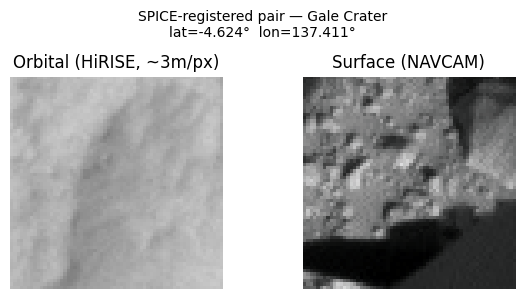

Figure 1 saved.


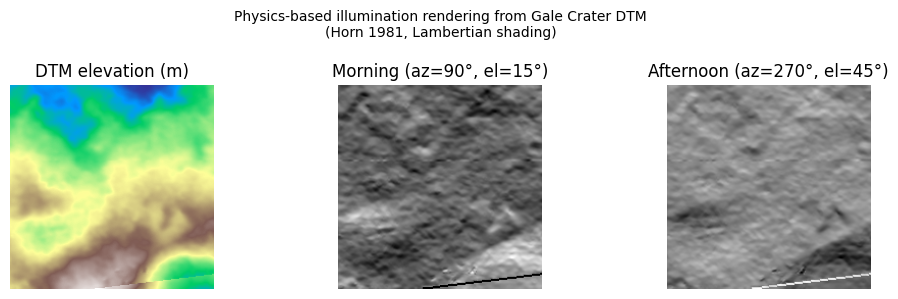

Figure 2 saved.


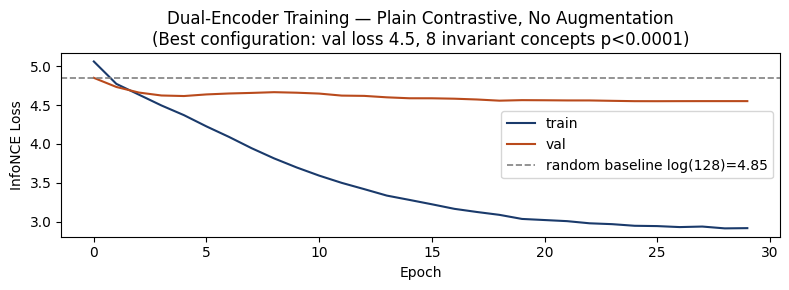

Figure 3 saved.


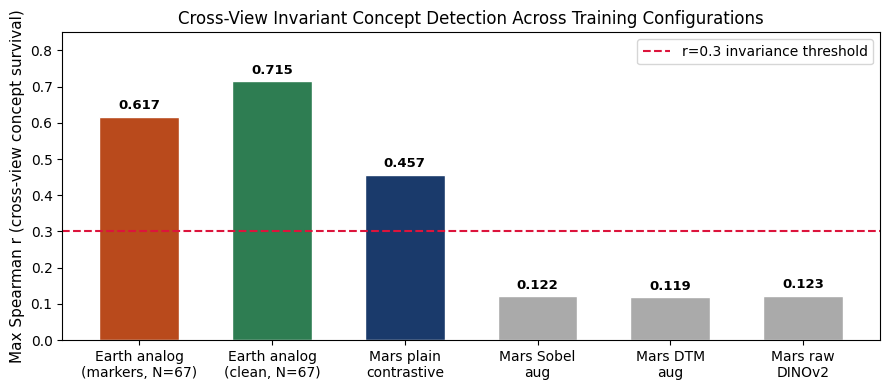

Figure 4 saved.

All figures saved to /content/drive/MyDrive/FAIMM/figures


In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from pathlib import Path

FIG_DIR = Path('/content/drive/MyDrive/FAIMM/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Figure 1: Sample HiRISE/NAVCAM pair ──────────────────────────────────────
orb, surf = dataset[0]
mean_ = np.array([0.485,0.456,0.406])[:,None,None]
std_  = np.array([0.229,0.224,0.225])[:,None,None]
orb_disp  = np.clip((orb.numpy()  * std_ + mean_).transpose(1,2,0), 0, 1)
surf_disp = np.clip((surf.numpy() * std_ + mean_).transpose(1,2,0), 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(orb_disp, cmap='gray'); axes[0].set_title('Orbital (HiRISE, ~3m/px)'); axes[0].axis('off')
axes[1].imshow(surf_disp);             axes[1].set_title('Surface (NAVCAM)');          axes[1].axis('off')
plt.suptitle(f'SPICE-registered pair — Gale Crater\nlat={pairs[0]["lat"]:.3f}°  lon={pairs[0]["lon"]:.3f}°', fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_sample_pair.png', dpi=150, bbox_inches='tight')
plt.show(); print('Figure 1 saved.')

# ── Figure 2: DTM illumination rendering ─────────────────────────────────────
import math
test_patch = get_dtm_patch(pairs[0]['lat'], pairs[0]['lon'])
normals    = compute_normals(np.nan_to_num(test_patch, nan=float(np.nanmean(test_patch))))
shade_a    = render_shading(normals, sun_azimuth_deg=90,  sun_elevation_deg=15)
shade_b    = render_shading(normals, sun_azimuth_deg=270, sun_elevation_deg=45)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(test_patch, cmap='terrain'); axes[0].set_title('DTM elevation (m)');     axes[0].axis('off')
axes[1].imshow(shade_a,    cmap='gray');    axes[1].set_title('Morning (az=90°, el=15°)');  axes[1].axis('off')
axes[2].imshow(shade_b,    cmap='gray');    axes[2].set_title('Afternoon (az=270°, el=45°)'); axes[2].axis('off')
plt.suptitle('Physics-based illumination rendering from Gale Crater DTM\n(Horn 1981, Lambertian shading)', fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_dtm_rendering.png', dpi=150, bbox_inches='tight')
plt.show(); print('Figure 2 saved.')

# ── Figure 3: Training loss curve (load from saved history) ──────────────────
hist_path = Path('/content/drive/MyDrive/FAIMM/mars_crossview_audit/encoder_history.npy')
if hist_path.exists():
    history = np.load(hist_path, allow_pickle=True).item()
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(history['train_loss'], label='train', color='#1A3A6B')
    ax.plot(history['val_loss'],   label='val',   color='#B94A1C')
    ax.axhline(np.log(128), color='gray', lw=1.2, ls='--', label='random baseline log(128)=4.85')
    ax.set(xlabel='Epoch', ylabel='InfoNCE Loss',
           title='Dual-Encoder Training — Plain Contrastive, No Augmentation\n(Best configuration: val loss 4.5, 8 invariant concepts p<0.0001)')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig3_training_curve.png', dpi=150, bbox_inches='tight')
    plt.show(); print('Figure 3 saved.')
else:
    print('encoder_history.npy not found — retrain or point to correct checkpoint dir.')

# ── Figure 4: Max r comparison bar chart ─────────────────────────────────────
configs = [
    'Earth analog\n(markers, N=67)',
    'Earth analog\n(clean, N=67)',
    'Mars plain\ncontrastive',
    'Mars Sobel\naug',
    'Mars DTM\naug',
    'Mars raw\nDINOv2',
]
max_r  = [0.617, 0.715, 0.457, 0.122, 0.119, 0.123]
colors = ['#B94A1C', '#2E7D52', '#1A3A6B', '#AAAAAA', '#AAAAAA', '#AAAAAA']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(configs, max_r, color=colors, edgecolor='white', width=0.6)
ax.axhline(0.3, color='crimson', lw=1.5, ls='--', label='r=0.3 invariance threshold')
ax.set_ylabel('Max Spearman r (cross-view concept survival)', fontsize=11)
ax.set_title('Cross-View Invariant Concept Detection Across Training Configurations', fontsize=12)
ax.set_ylim(0, 0.85)
ax.legend(fontsize=10)
for bar, val in zip(bars, max_r):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.3f}', ha='center', fontsize=9.5, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_max_r_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); print('Figure 4 saved.')

print(f'\nAll figures saved to {FIG_DIR}')